/projects/ezorzetto@xsede.org/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_4_3d/


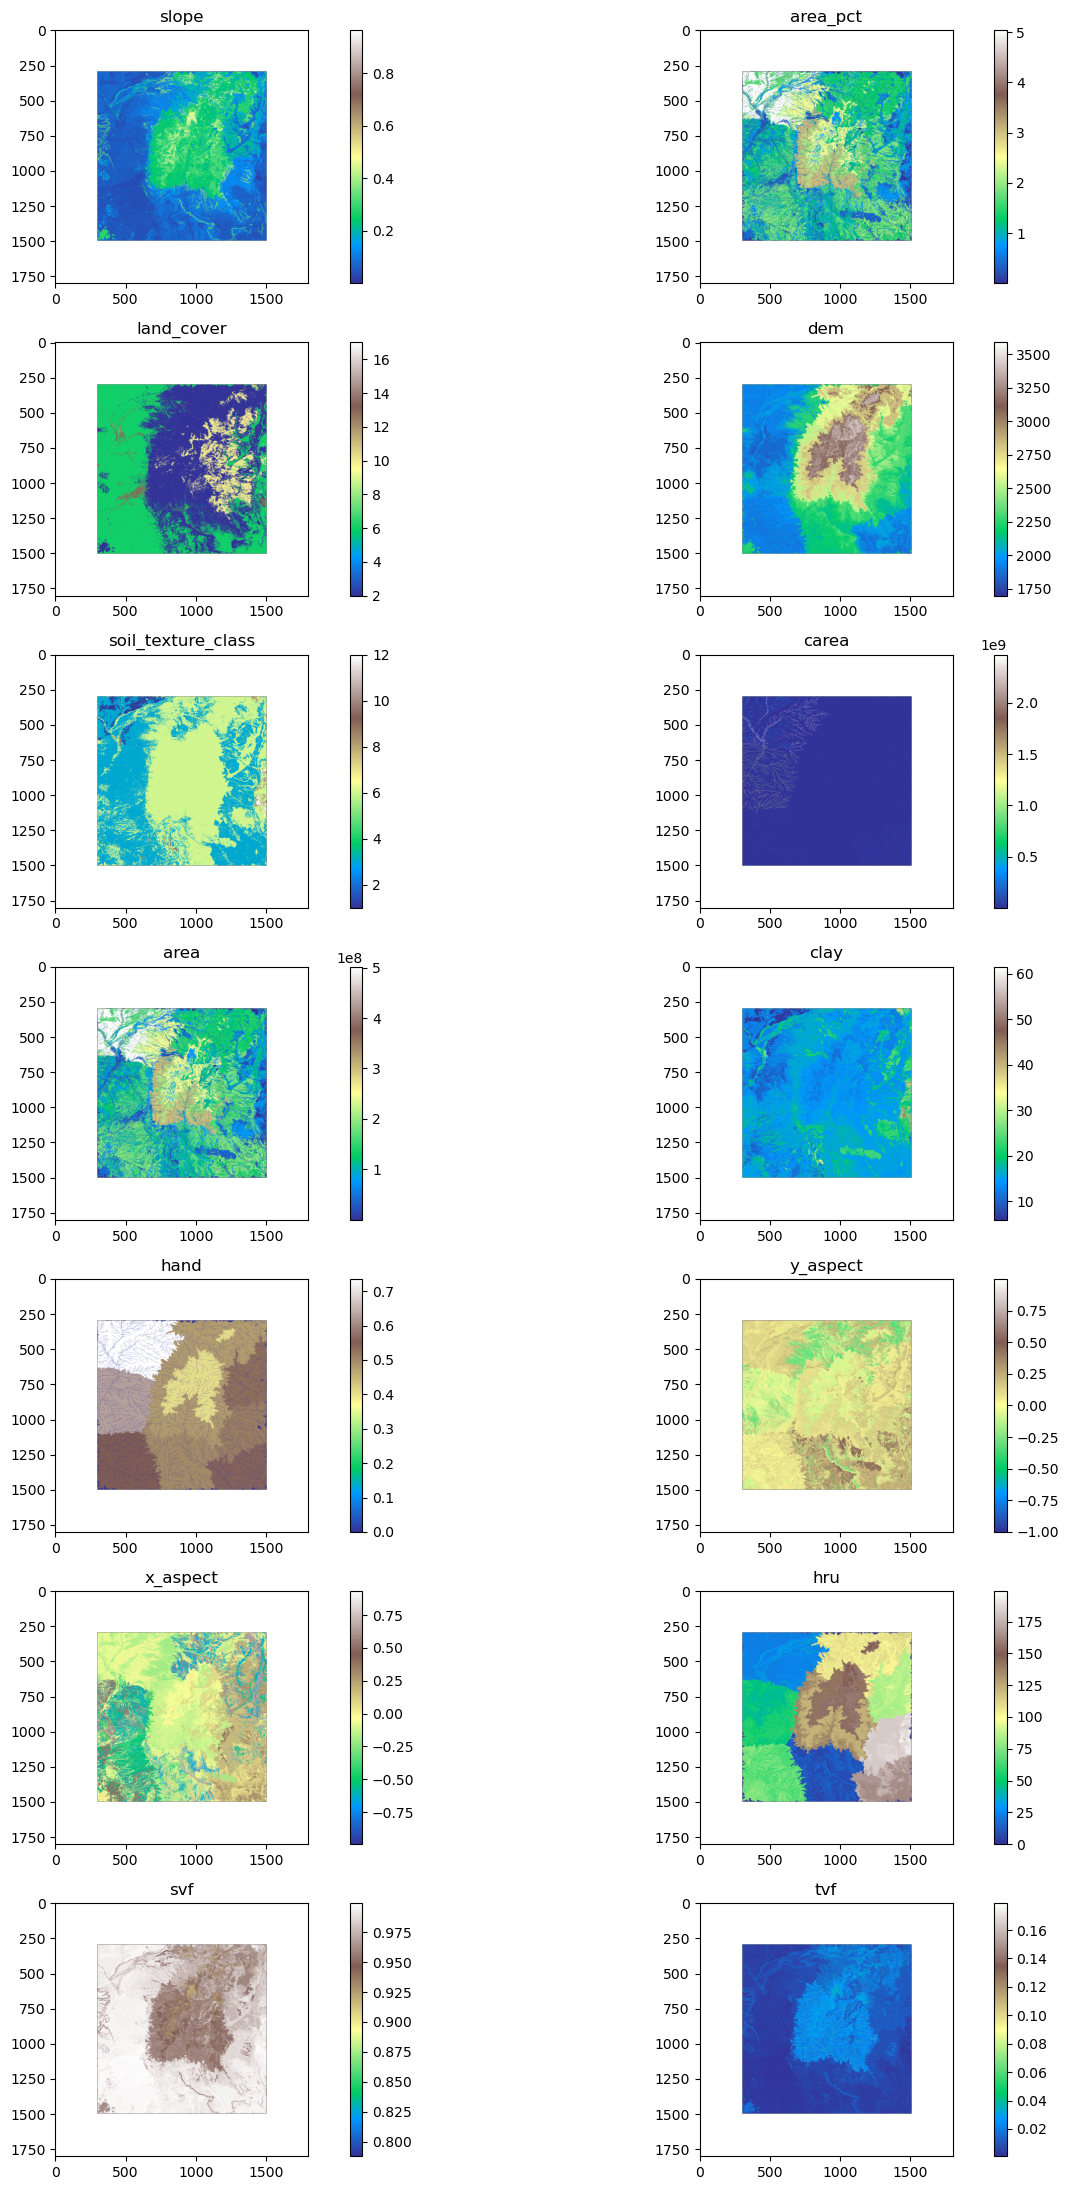

In [20]:
import numpy as np
import netCDF4 as nc
import numba
# import geospatialtools.gdal_tools as gdal_tools
import gdal_tools
import sys
import matplotlib.pyplot as plt
import rasterio
import os 

# @numba.jit()
def place_data(tmp, model, hrus, cids, val):
    for i in range(tmp.shape[0]):
        for j in range(tmp.shape[1]):
            hru = int(hrus[i,j])
            ucid = int(cids[i,j])
            if (hru != -9999) & (ucid == val):
                tmp[i,j] = model[hru]
    return tmp

# Path setup
path = '/projects/ezorzetto@xsede.org/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_4_3d/'
print(path)

var2plot = ["slope", "area_pct", "land_cover", "dem", "soil_texture_class", 
            "carea", "area", "clay", "hand", "y_aspect", "x_aspect", "hru","svf","tvf"]

hrus = gdal_tools.read_raster('/projects/ezorzetto@xsede.org/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_4_3d/postprocess/hrus.vrt')

cids = gdal_tools.read_raster(path + 'postprocess/cids.vrt')
tmp = np.copy(hrus)
tmp[:] = -9999.0

# Create a 6x2 grid of subplots
fig, axes = plt.subplots(7, 2, figsize=(15, 22))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Loop over the variables in var2plot and plot each in a subplot
for j, ax in enumerate(axes):
    var = var2plot[j]
    if j >= len(var2plot):
        # If there are more subplots than variables, hide the extra axes
        ax.axis('off')
        continue


    for c in range(1, 2):
        fp = nc.Dataset(path + '%s/input_file.nc' % c)
        if var in ["lwdown","swdown"]:
            grp = fp.groups['meteorology']
        else:
            grp = fp.groups['parameters']
        
        data = np.array(grp.variables[var2plot[j]][:])
        final_map = place_data(tmp, data, hrus, cids, int(c))
    
    # Mask out invalid values
    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map==-9999] = np.nan
    # Plot in the corresponding subplot
    hru_path = "/projects/ezorzetto@xsede.org/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_4_3d/postprocess/hrus/1.tif"
    hru = rasterio.open(hru_path)
    im = ax.imshow(final_map, cmap='terrain')
    ax.set_title(var2plot[j])  # Set the title for each subplot
    fig.colorbar(im, ax=ax)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()




#


In [46]:
    import pandas as pd
    for c in range(1, 2):
        fp = nc.Dataset(path + '%s/input_file.nc' % c)
        group_keys = fp.groups.keys()

        print("Group Keys:", group_keys)
        time = fp.groups['meteorology']['time'][:]

        print("Group Keys:", group_keys)

        # You can then iterate through these keys to access each specific group
        for group_name in group_keys:
            print(f"\nContents of group: '{group_name}'")
            group = fp.groups[group_name]
        
            # Print variables within the group
            print("  Variables:", group.variables.keys())

            # Print subgroups within the group
            print("  Subgroups:", group.groups.keys())


        print(time.shape)
        print(time[:4])
        print(time[-4:])


    # get time axis
    start_date = '2014-01-01'
    start = pd.Timestamp("2014-01-01 00:00")
    datetime_series = start + pd.to_timedelta(time, unit="h")
    datetime_series = datetime_series.tz_localize("UTC")
    times = pd.Series(datetime_series, name="datetime")

    # start_colorado = start.tz_convert("America/Denver")
    # datetime_colorado = start_colorado + pd.to_timedelta(time, unit="h")
    # times = pd.Series(datetime_colorado, name="datetime_mt")

    


    datetime_series = datetime_series.tz_convert("America/Denver")
    times = pd.Series(datetime_series, name="datetime")

Group Keys: dict_keys(['meteorology', 'water_use', 'metadata', 'wmatrix_Basin1', 'wmatrix_Basin2', 'wmatrix_Basin3', 'wmatrix_Basin4', 'wmatrix_Basin5', 'wmatrix_Basin6', 'wmatrix_Basin7', 'wmatrix_Basin8', 'wmatrix_Basin9', 'wmatrix_Basin10', 'parameters', 'stream_network'])
Group Keys: dict_keys(['meteorology', 'water_use', 'metadata', 'wmatrix_Basin1', 'wmatrix_Basin2', 'wmatrix_Basin3', 'wmatrix_Basin4', 'wmatrix_Basin5', 'wmatrix_Basin6', 'wmatrix_Basin7', 'wmatrix_Basin8', 'wmatrix_Basin9', 'wmatrix_Basin10', 'parameters', 'stream_network'])

Contents of group: 'meteorology'
  Variables: dict_keys(['lwdown', 'swdown', 'tair', 'precip', 'psurf', 'wind', 'spfh', 'time'])
  Subgroups: dict_keys([])

Contents of group: 'water_use'
  Variables: dict_keys([])
  Subgroups: dict_keys([])

Contents of group: 'metadata'
  Variables: dict_keys([])
  Subgroups: dict_keys([])

Contents of group: 'wmatrix_Basin1'
  Variables: dict_keys(['data', 'indices', 'indptr'])
  Subgroups: dict_keys([])


In [68]:
print(times[:10])
print(times[-5:])
print(len(times))

# index8am = (times.dt.hour >= 7) & (times.dt.hour <= 9) & (times.dt.month == 5)
index8am = (times.dt.hour >= 16) & (times.dt.hour <= 18) & (times.dt.month == 5)
times8am = times[index8am]
print(len(times8am))

print(times8am[:10])
print(times8am[-5:])

0   2013-12-31 17:00:00-07:00
1   2013-12-31 20:00:00-07:00
2   2013-12-31 23:00:00-07:00
3   2014-01-01 02:00:00-07:00
4   2014-01-01 05:00:00-07:00
5   2014-01-01 08:00:00-07:00
6   2014-01-01 11:00:00-07:00
7   2014-01-01 14:00:00-07:00
8   2014-01-01 17:00:00-07:00
9   2014-01-01 20:00:00-07:00
Name: datetime, dtype: datetime64[ns, America/Denver]
2899   2014-12-29 02:00:00-07:00
2900   2014-12-29 05:00:00-07:00
2901   2014-12-29 08:00:00-07:00
2902   2014-12-29 11:00:00-07:00
2903   2014-12-29 14:00:00-07:00
Name: datetime, dtype: datetime64[ns, America/Denver]
2904
31
968    2014-05-01 18:00:00-06:00
976    2014-05-02 18:00:00-06:00
984    2014-05-03 18:00:00-06:00
992    2014-05-04 18:00:00-06:00
1000   2014-05-05 18:00:00-06:00
1008   2014-05-06 18:00:00-06:00
1016   2014-05-07 18:00:00-06:00
1024   2014-05-08 18:00:00-06:00
1032   2014-05-09 18:00:00-06:00
1040   2014-05-10 18:00:00-06:00
Name: datetime, dtype: datetime64[ns, America/Denver]
1176   2014-05-27 18:00:00-06:00
11

In [48]:
 print(data.shape)
 print(tmp.shape)

(200,)
(1801, 1801)


/projects/ezorzetto@xsede.org/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_4_3d/


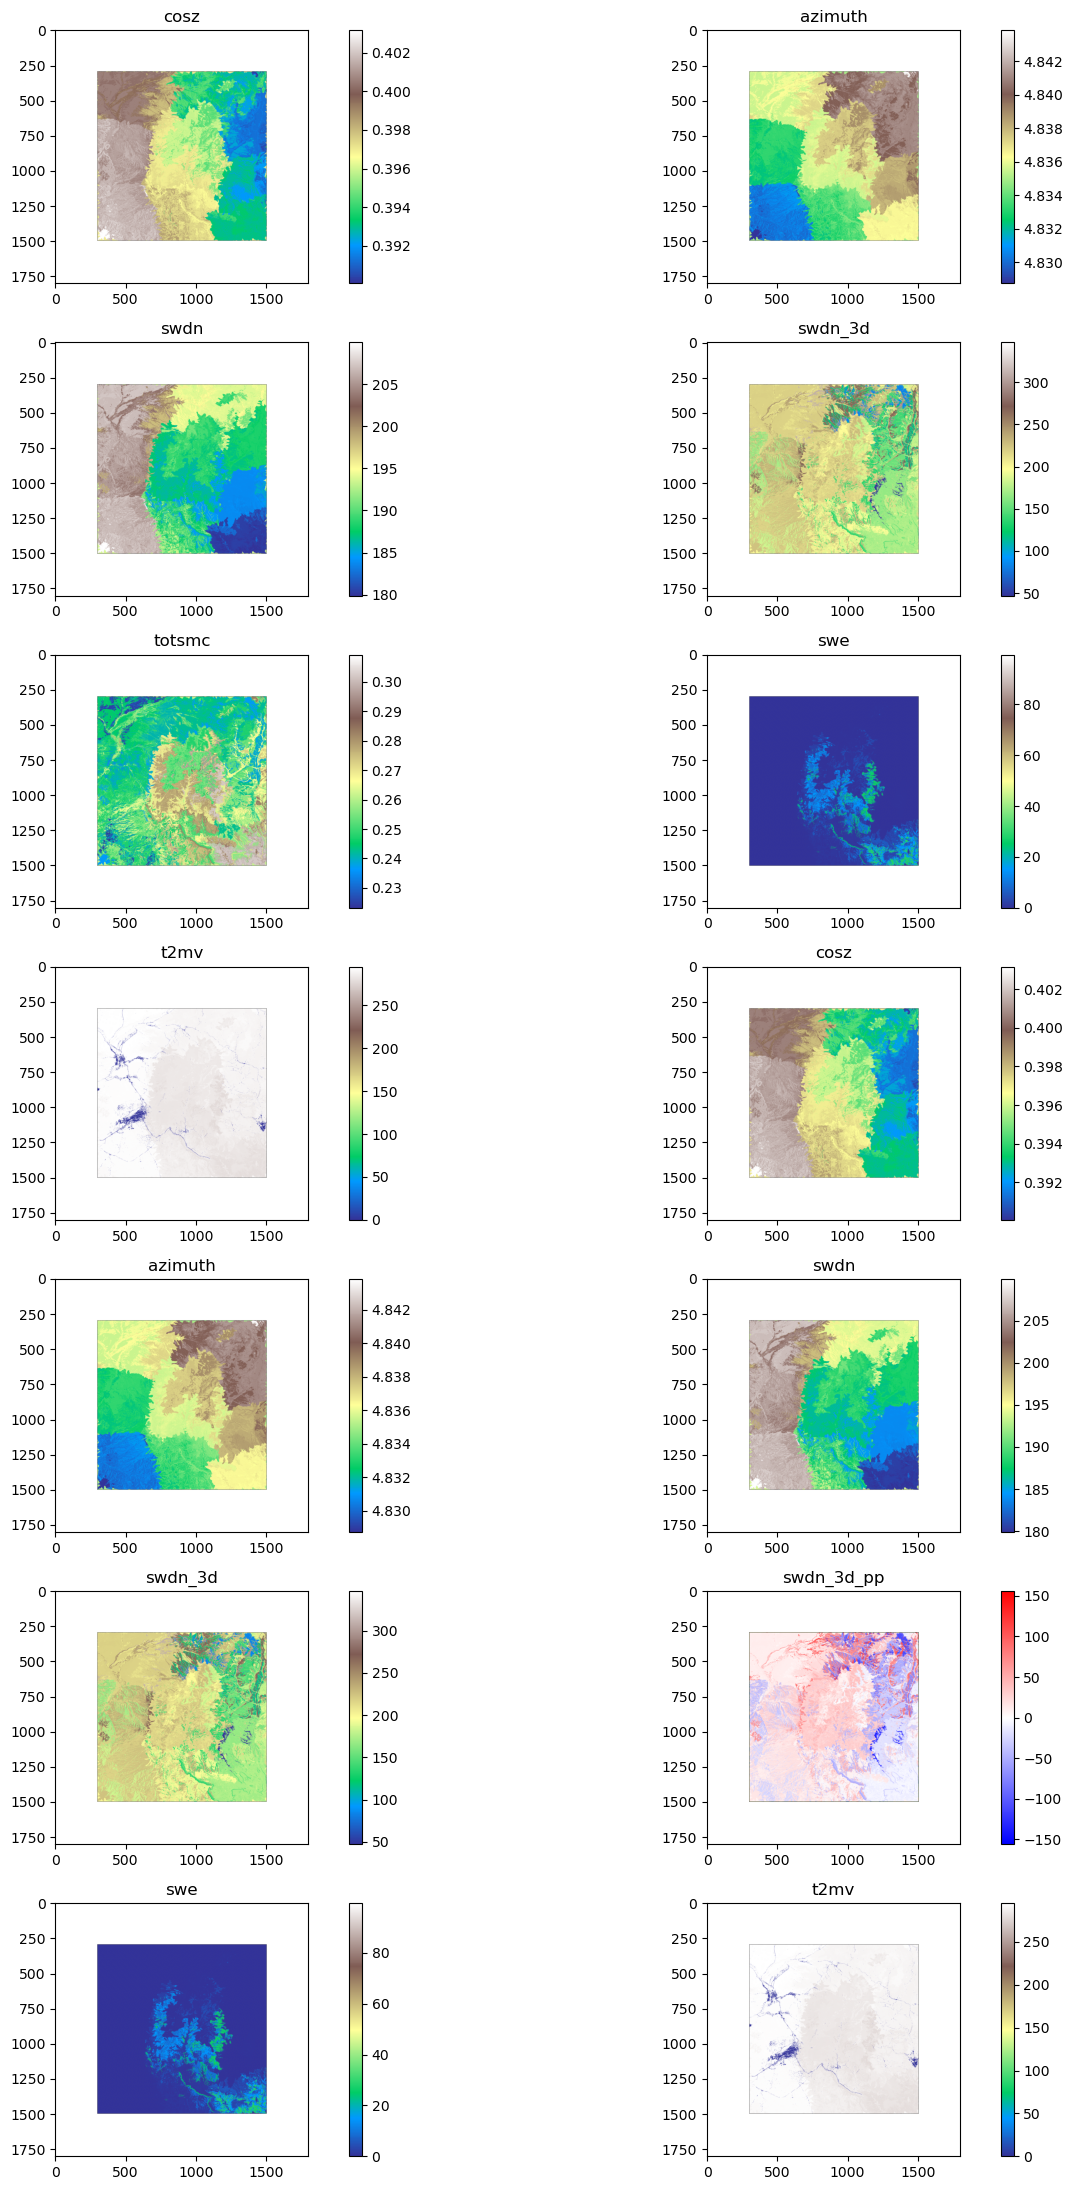

In [69]:
import numpy as np
import netCDF4 as nc
import numba
# import geospatialtools.gdal_tools as gdal_tools
import gdal_tools
import sys
import matplotlib.pyplot as plt
import rasterio
import os 
import matplotlib.colors as colors

# @numba.jit()
def place_data(tmp, model, hrus, cids, val):
    for i in range(tmp.shape[0]):
        for j in range(tmp.shape[1]):
            hru = int(hrus[i,j])
            ucid = int(cids[i,j])
            if (hru != -9999) & (ucid == val):
                tmp[i,j] = model[hru]
    return tmp

# Path setup
path = '/projects/ezorzetto@xsede.org/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_4_3d/'
print(path)



var2plot = ["cosz", "azimuth", "swdn", "swdn_3d", "totsmc", "swe", "t2mv",
                "cosz", "azimuth", "swdn", "swdn_3d", "swdn_3d_pp", "swe", "t2mv"]

hrus = gdal_tools.read_raster('/projects/ezorzetto@xsede.org/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_4_3d/postprocess/hrus.vrt')

cids = gdal_tools.read_raster(path + 'postprocess/cids.vrt')
tmp = np.copy(hrus)
tmp[:] = -9999.0

# Create a 6x2 grid of subplots
fig, axes = plt.subplots(7, 2, figsize=(15, 22))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Loop over the variables in var2plot and plot each in a subplot
for j, ax in enumerate(axes):
    var = var2plot[j]
    if j >= len(var2plot):
        # If there are more subplots than variables, hide the extra axes
        ax.axis('off')
        continue


    for c in range(1, 2):
        fp = nc.Dataset(path + '/output_data/1/2014-01-01.nc')
        if var in ["swdn_3d_pp"]:
            grp = fp.groups['data']
            data3d = np.array(grp.variables['swdn_3d'][:])
            datapp = np.array(grp.variables['swdn'][:])
            data = data3d - datapp
        else:
            grp = fp.groups['data']
            data = np.array(grp.variables[var2plot[j]][:])
        
        

        data_sel = data[index8am,:]
        data_ave = np.mean(data_sel, axis=0)

        final_map = place_data(tmp, data_ave, hrus, cids, int(c))
    
    # Mask out invalid values
    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map==-9999] = np.nan
    # Plot in the corresponding subplot
    hru_path = "/projects/ezorzetto@xsede.org/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_4_3d/postprocess/hrus/1.tif"
    hru = rasterio.open(hru_path)
    im = ax.imshow(final_map, cmap='terrain')
    if var in ["swdn_3d_pp"]:
        mymin = np.abs(np.nanmin(final_map))
        mymax = np.abs(np.nanmax(final_map))
        diff_norm = colors.TwoSlopeNorm(
            vmin=-max(mymin, mymax),
            vcenter=0.0,
            vmax= max(mymin, mymax)
            )
        im = ax.imshow(final_map, cmap='bwr', norm=diff_norm)
    ax.set_title(var2plot[j])  # Set the title for each subplot
    fig.colorbar(im, ax=ax)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()




#


In [ ]:
 print(data.shape)
 print(tmp.shape)